# **Persiapan dataset**

In [ ]:
!pip install kaggle

In [ ]:
kaggle = '/content/kaggle.json'

In [ ]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
  0% 0.00/66.7M [00:00<?, ?B/s]
100% 66.7M/66.7M [00:00<00:00, 1.52GB/s]


In [ ]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = "data"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [ ]:
import os
data_0 = os.listdir('data/0')
data_1 = os.listdir('data/1')
data_2 = os.listdir('data/2')
data_3 = os.listdir('data/3')
data_4 = os.listdir('data/4')
data_5 = os.listdir('data/5')
data_6 = os.listdir('data/6')
data_7 = os.listdir('data/7')
data_8 = os.listdir('data/8')
data_9 = os.listdir('data/9')

In [ ]:
len(data_0)

2236

# **Import Library**

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# **Preprocessing data**
Ubah gambar MNIST menjadi Data Numerik

* 21555 → total gambar digit yang berhasil dibaca
* 784 → hasil flatten dari gambar 28×28 (28 × 28 = 784)
* Setiap 1 baris di X = 1 gambar digit
* y berisi label angka 0 sampai 9 untuk tiap gambar

In [ ]:
DATA_DIR = "data"
IMG_SIZE = 28

X = []
y = []

for label in range(10):
    folder_path = os.path.join(DATA_DIR, str(label))

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        # Baca gambar grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # Resize ke 28x28
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Invers warna (penting!)
        img = cv2.bitwise_not(img)

        # Normalisasi pixel
        img = img / 255.0

        # Flatten jadi 784 fitur
        img = img.flatten()

        X.append(img)
        y.append(label)

# Konversi ke numpy array
X = np.array(X).astype("float32")
y = np.array(y)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (21555, 784)
Shape y: (21555,)


# **Encoding label dan Split data**

* Data terbagi 80% training dan 20% testing
* Input sudah berbentuk vektor 784 fitur
* Label sudah one-hot encoding (10 kelas: 0–9)

In [ ]:
# One-hot encoding label
y_encoded = to_categorical(y, num_classes=10)

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (17244, 784)
X_test : (4311, 784)
y_train: (17244, 10)
y_test : (4311, 10)


# **Pembuatan Model ANN (MPL)**

* Input: 784 neuron (hasil flatten gambar 28×28)
* Hidden layer 1: 128 neuron + ReLU
* Hidden layer 2: 64 neuron + ReLU
* Output layer: 10 neuron + Softmax
* Total parameter: 109.386

In [ ]:
model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# **Training model + Early Stopping**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2874 - loss: 2.0314 - val_accuracy: 0.5590 - val_loss: 1.3876
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5514 - loss: 1.4018 - val_accuracy: 0.6700 - val_loss: 1.0609
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6532 - loss: 1.0974 - val_accuracy: 0.7396 - val_loss: 0.8565
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7077 - loss: 0.9098 - val_accuracy: 0.7785 - val_loss: 0.7376
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7481 - loss: 0.7873 - val_accuracy: 0.8084 - val_loss: 0.6404
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7838 - loss: 0.6794 - val_accuracy: 0.8214 - val_loss: 0.5740
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8099 - loss: 0.5943 - val_accuracy: 0.8327 - val_loss: 0.5415
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8207 - loss: 0.5499 - val_accuracy: 0.

# **Evaluasi Model (testing Data)**

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

Test Accuracy: 0.8700997233390808
Test Loss: 0.44922658801078796


# **Visualisasi Accuracy dan Loss**

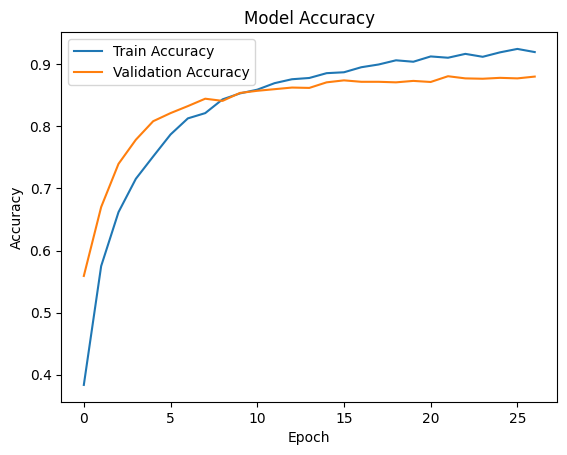

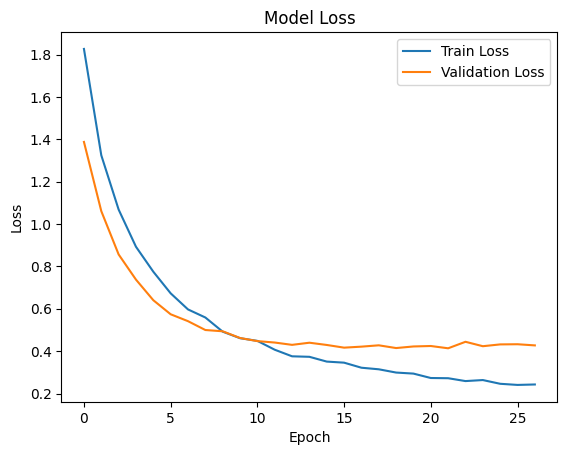

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()